# Training Results

Loss curves, in-loop LFW accuracy, and a t-SNE projection of validation embeddings from the best checkpoint.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
hist = json.loads((ROOT / 'training_pipeline/checkpoints/history.json').read_text())
print(f'Epochs run:        {len(hist["train_loss"])}')
print(f'Final train loss:  {hist["train_loss"][-1]:.4f}')
print(f'Best LFW acc:      {max(hist["lfw_acc"]):.4f}')

Epochs run:        20
Final train loss:  0.1407
Best LFW acc:      0.9760


## Model summary


In [2]:
# Model summary (PyTorch equivalent of Keras `model.summary()`).
import sys
sys.path.insert(0, str(ROOT))

import torch
from training_pipeline.src.model import FaceEmbedding

ckpt = torch.load(ROOT / 'application/models/best.pt', map_location='cpu', weights_only=False)
model = FaceEmbedding(embedding_dim=ckpt['cfg']['train']['embedding_dim'], pretrained=False)
model.load_state_dict(ckpt['model'])
model.eval()

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {n_params:,}')
print(f'Trainable parameters: {n_trainable:,}')
print(f'Embedding dim:        {ckpt["cfg"]["train"]["embedding_dim"]}')
print(f'Loss:                 batch-hard triplet (margin={ckpt["cfg"]["train"]["margin"]})')
print()
print(model)


Total parameters:     24,557,120
Trainable parameters: 24,557,120
Embedding dim:        512
Loss:                 batch-hard triplet (margin=0.3)

FaceEmbedding(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchN

## Per-epoch log


In [3]:
# Per-epoch training log (Kaggle-style epoch-by-epoch table).
import pandas as pd

log = pd.DataFrame({
    'epoch': range(1, len(hist['train_loss']) + 1),
    'train_loss': hist['train_loss'],
    'lfw_acc_inloop': hist['lfw_acc'],
})
log


,epoch,train_loss,lfw_acc_inloop
0,1,0.333840,0.976
1,2,0.308236,0.976
2,3,0.307170,0.976
3,4,0.306621,0.976
4,5,0.305929,0.976
5,6,0.304656,0.976
6,7,0.302953,0.976
7,8,0.300324,0.976
8,9,0.293795,0.970
9,10,0.259045,0.969


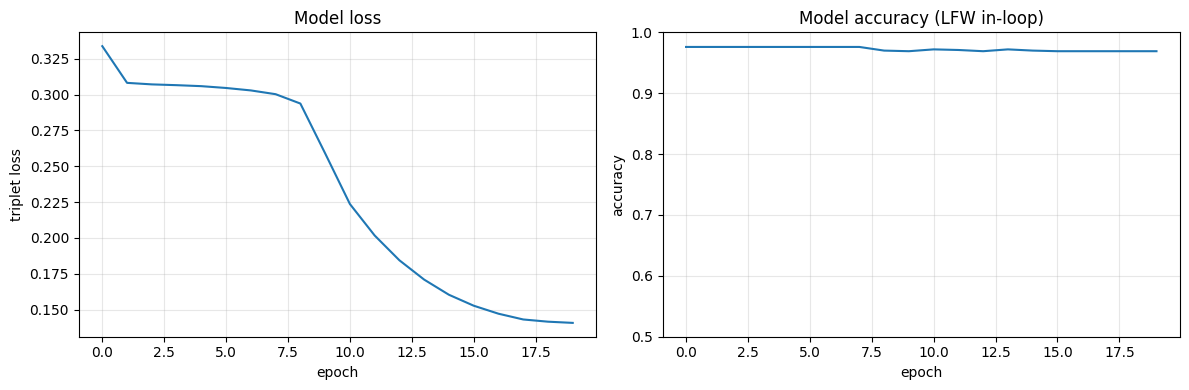

In [4]:
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4))
a.plot(hist['train_loss'])
a.set_title('Model loss')
a.set_xlabel('epoch')
a.set_ylabel('triplet loss')
a.grid(True, alpha=0.3)
b.plot(hist['lfw_acc'])
b.set_title('Model accuracy (LFW in-loop)')
b.set_xlabel('epoch')
b.set_ylabel('accuracy')
b.set_ylim(0.5, 1.0)
b.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

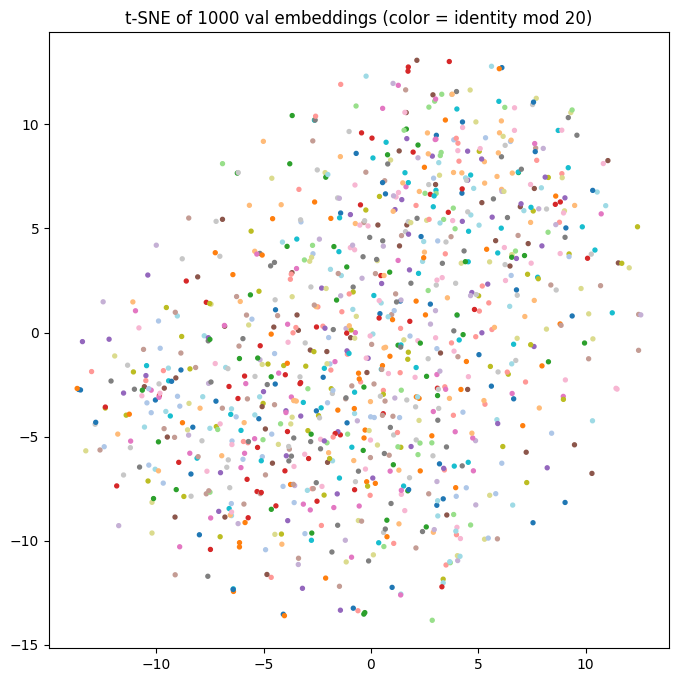

In [5]:
import sys
sys.path.insert(0, str(ROOT))

import torch
import numpy as np
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader
from training_pipeline.src.dataset import FaceDataset, eval_transform
from training_pipeline.src.model import FaceEmbedding

ckpt = torch.load(ROOT / 'training_pipeline/checkpoints/best.pt', map_location='cpu')
model = FaceEmbedding(embedding_dim=ckpt['cfg']['train']['embedding_dim'], pretrained=False)
model.load_state_dict(ckpt['model'])
model.eval()

ds = FaceDataset(ROOT / 'process-data/manifest.parquet', split='val', transform=eval_transform())
n_sample = min(1000, len(ds))
idxs = np.random.RandomState(0).choice(len(ds), size=n_sample, replace=False)
imgs = torch.stack([ds[i][0] for i in idxs])
labels = np.array([ds[i][1] for i in idxs])

with torch.no_grad():
    emb = model(imgs).cpu().numpy()

z = TSNE(n_components=2, random_state=0, perplexity=30, init='pca').fit_transform(emb)
plt.figure(figsize=(8, 8))
plt.scatter(z[:, 0], z[:, 1], c=labels % 20, s=8, cmap='tab20')
plt.title(f't-SNE of {n_sample} val embeddings (color = identity mod 20)')
plt.show()

In [6]:
# Hyperparameters used.
cfg = ckpt['cfg']
tbl = {**cfg['train'], 'eval_max_pairs_inloop': cfg['eval']['max_pairs_inloop']}
import pandas as pd
pd.DataFrame(tbl.items(), columns=['param', 'value'])

,param,value
0,epochs,20.00000
1,p,32.00000
2,k,4.00000
3,batches_per_epoch,1500.00000
4,margin,0.30000
5,lr_head,0.00030
6,lr_backbone,0.00003
7,weight_decay,0.00010
8,warmup_steps,500.00000
9,num_workers,8.00000
